<a href="https://colab.research.google.com/github/catarina1532/pml/blob/main/C%C3%B3pia_de_land_use_classification_with_resnet_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Use Classification of Satellite Imagery Using Transfer Learning with ResNet18 (EuroSAT)

## Introduction

The objective of this project is to classify satellite images from the EuroSAT dataset into ten land-use categories using Deep Learning techniques. This problem corresponds to a supervised multiclass image classification task where the input consists of RGB satellite images and the output is one of ten land-cover classes.

Some land-cover categories present high visual similarity. For example, HerbaceousVegetation, Pasture, and PermanentCrop often share similar textures and color patterns. Additionally, satellite imagery may exhibit variations in illumination and geographic conditions, increasing intra-class variability and making classification more challenging.

A custom CNN architecture could be designed and trained for this task; however, transfer learning with a pre-trained ResNet18 model was selected because it reduces computational requirements while leveraging visual features previously learned from ImageNet and adapting them to satellite imagery through fine-tuning.

The project workflow consists of dataset preparation, preprocessing and augmentation, transfer learning using a pre-trained ResNet18 architecture, model fine-tuning, and performance evaluation through multiple classification metrics.

## Importing Dependencies

This section imports the libraries required throughout the project. The selected packages support numerical operations, data manipulation, visualization, dataset handling, deep learning implementation with PyTorch, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

from sklearn.metrics import (classification_report, confusion_matrix)

from pathlib import Path

!pip install split-folders

import splitfolders

The imported libraries provide the complete environment required for implementing the deep learning pipeline. PyTorch serves as the main framework for model development, while supporting libraries such as NumPy, Pandas and Scikit-learn facilitate preprocessing and evaluation tasks.

## Reproducibility

Reproducibility is an important aspect of machine learning experiments. Random seeds are fixed to reduce variability caused by random initialization and dataset shuffling.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

By fixing random seeds, repeated executions are expected to produce similar dataset splits and parameter initialization. Although GPU operations may still introduce small variations, reproducibility is substantially improved.

## Device Selection

Deep learning training can be computationally expensive. Therefore, the execution device is automatically selected according to hardware availability.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

GPU acceleration significantly reduces training time by parallelizing matrix operations required during forward and backward propagation.

## Dataset Acquisition and Exploration

### Dataset Download and Loading

The EuroSAT RGB dataset is used as the benchmark dataset for this project. The dataset consists of Sentinel-2 satellite images categorized into ten land-use classes.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waseemalastal/eurosat-rgb-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-rgb-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-rgb-dataset


***prompt***: load the eurosat dataset using imagefolder

In [ ]:
dataset_path = Path(path)

data = datasets.ImageFolder(root=dataset_path / "EuroSAT_RGB")

print("Number of images:", len(data))
print("Number of classes:", len(data.classes))
print("Classes:", data.classes)

Number of images: 27000
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


The dataset contains 27,000 RGB satellite images distributed among ten land-use categories. The folder structure automatically allows ImageFolder to assign class labels based on directory names.

### Dataset Splitting

Since the original dataset does not provide predefined subsets, separate training, validation and testing datasets must be created. Proper partitioning enables unbiased performance evaluation.

***prompt***: split the eurosat dataset into train, validation and test sets using a 70–20–10 ratio

In [ ]:
dataset_path = Path(path) / "EuroSAT_RGB"

splitfolders.ratio(
    dataset_path,
    output="splitted_data",
    seed=SEED,
    ratio=(0.7, 0.2, 0.1)
)

Copying files: 27000 files [01:23, 321.89 files/s]


The dataset was divided into training (70%), validation (20%), and test (10%) subsets. The training subset supports model learning, the validation subset assists hyperparameter tuning and overfitting monitoring, while the test subset provides an unbiased estimate of model generalization.

Since the split is random rather than geographic, neighboring image patches may potentially appear in different subsets. Consequently, performance estimates could be slightly optimistic.

## Data Preprocessing and Exploratory Analysis

## Data Preprocessing and Augmentation

Deep learning architectures require input data with consistent dimensions and distributions. Image preprocessing standardizes input representations, while augmentation artificially increases training variability.

***prompt***: generate pytorch preprocessing code for eurosat images including resizing, normalization using imagenet statistics and data augmentation

***modification prompts***: add randomrotation(15), create separate transformations for training, validation and testing datasets

In [ ]:
#----------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------- Transformation for the Whole Dataset for Visualization Purposes --------
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train = datasets.ImageFolder(
    root="splitted_data/train",
    transform=train_transform
)

val = datasets.ImageFolder(
    root="splitted_data/val",
    transform=val_transform
)

test = datasets.ImageFolder(
    root="splitted_data/test",
    transform=test_transform
)

# -------- Getting the Whole Dataset for Visualization Purposes --------
data = datasets.ImageFolder(
    root=dataset_path,
    transform=data_transform
)


Images were resized to 224×224 pixels to match the input dimensions expected by ResNet18. Normalization using ImageNet statistics was applied because the pre-trained model was originally trained using these distributions. Data augmentation techniques such as random horizontal flipping and rotation were applied only to training data to improve robustness and reduce overfitting.

### Dataset Distribution Analysis

Before model training, class distributions should be examined to identify possible imbalance issues.

In [ ]:
print("Dataset Labels:")
print(train.class_to_idx)

idx_to_class = {v:k for k,v in train.class_to_idx.items()}

rows = []

for name, dataset in zip(
    ["Train","Validation","Test"],
    [train,val,test]
):
    counts = pd.Series(dataset.targets).value_counts().sort_index()

    for idx, count in counts.items():
        rows.append([name, idx_to_class[idx], count])

df_counts = pd.DataFrame(
    rows,
    columns=["Dataset","Class","Images"]
)

display(df_counts)

Dataset Labels:
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


,Dataset,Class,Images
0,Train,AnnualCrop,2100
1,Train,Forest,2100
2,Train,HerbaceousVegetation,2100
3,Train,Highway,1750
4,Train,Industrial,1750
5,Train,Pasture,1400
6,Train,PermanentCrop,1750
7,Train,Residential,2100
8,Train,River,1750
9,Train,SeaLake,2100


The class distribution is relatively balanced across all categories, with only minor differences between classes. Consequently, additional balancing techniques such as class weighting or oversampling were not considered necessary.

### Visual Inspection of Images

Visual inspection provides an intuitive understanding of class characteristics and allows preliminary identification of visually similar categories.

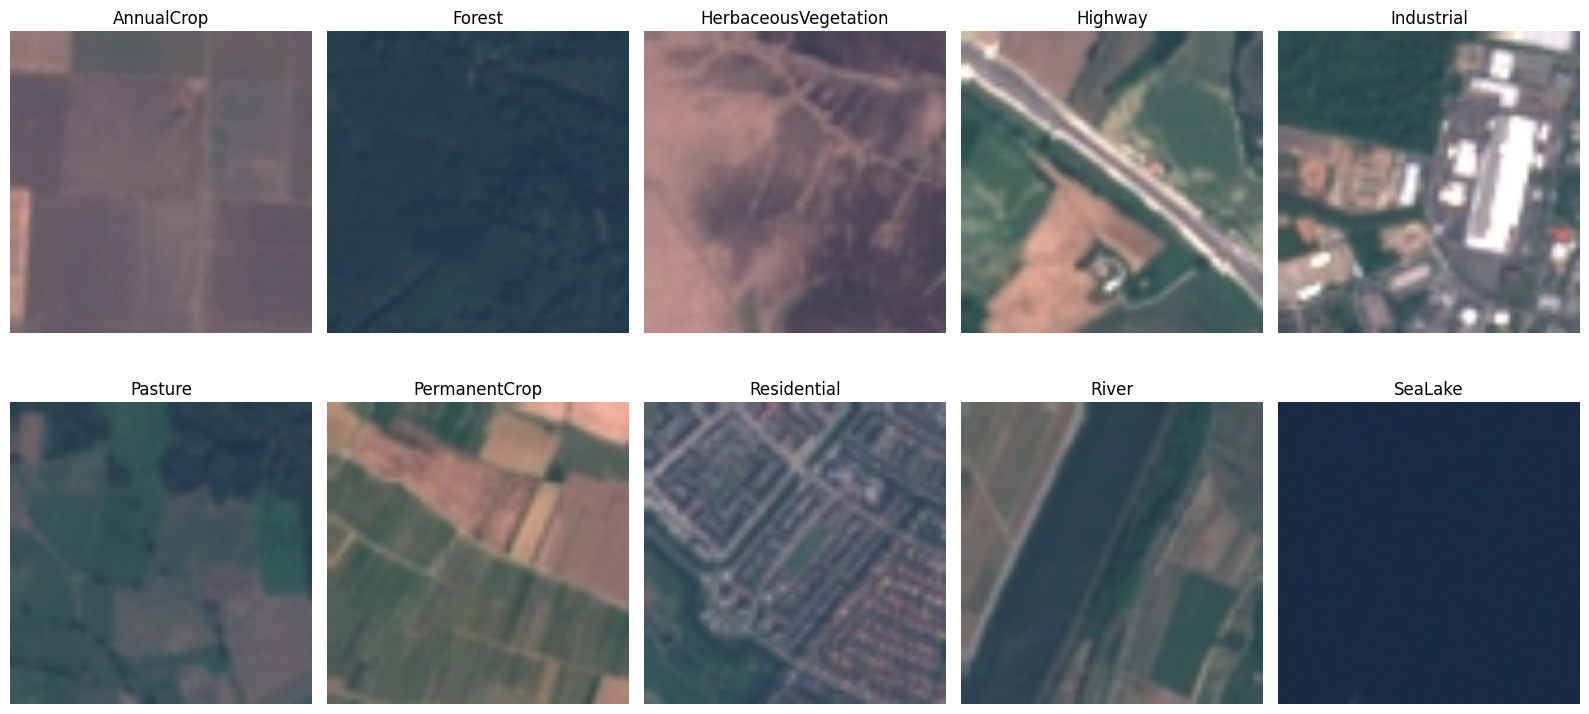

In [ ]:
labels_for_viz = {v: k for k, v in data.class_to_idx.items()}

fig, ax = plt.subplots(2, 5, figsize=(16, 8))
ax = ax.flatten()

for class_idx in range(len(labels_for_viz)):

    for i, (_, label) in enumerate(data):
        if label == class_idx:
            ax[class_idx].imshow(data[i][0].permute(1, 2, 0))
            ax[class_idx].set_title(labels_for_viz[class_idx])
            ax[class_idx].axis("off")
            break

plt.tight_layout()
plt.show()

Distinct visual patterns can be observed among several classes. However, some vegetation-related categories exhibit substantial visual overlap, suggesting that these classes may present higher classification difficulty.

### Visual Inspection of Augmented Images

Augmented samples are visualized to verify that transformations increase variability while preserving semantic information.

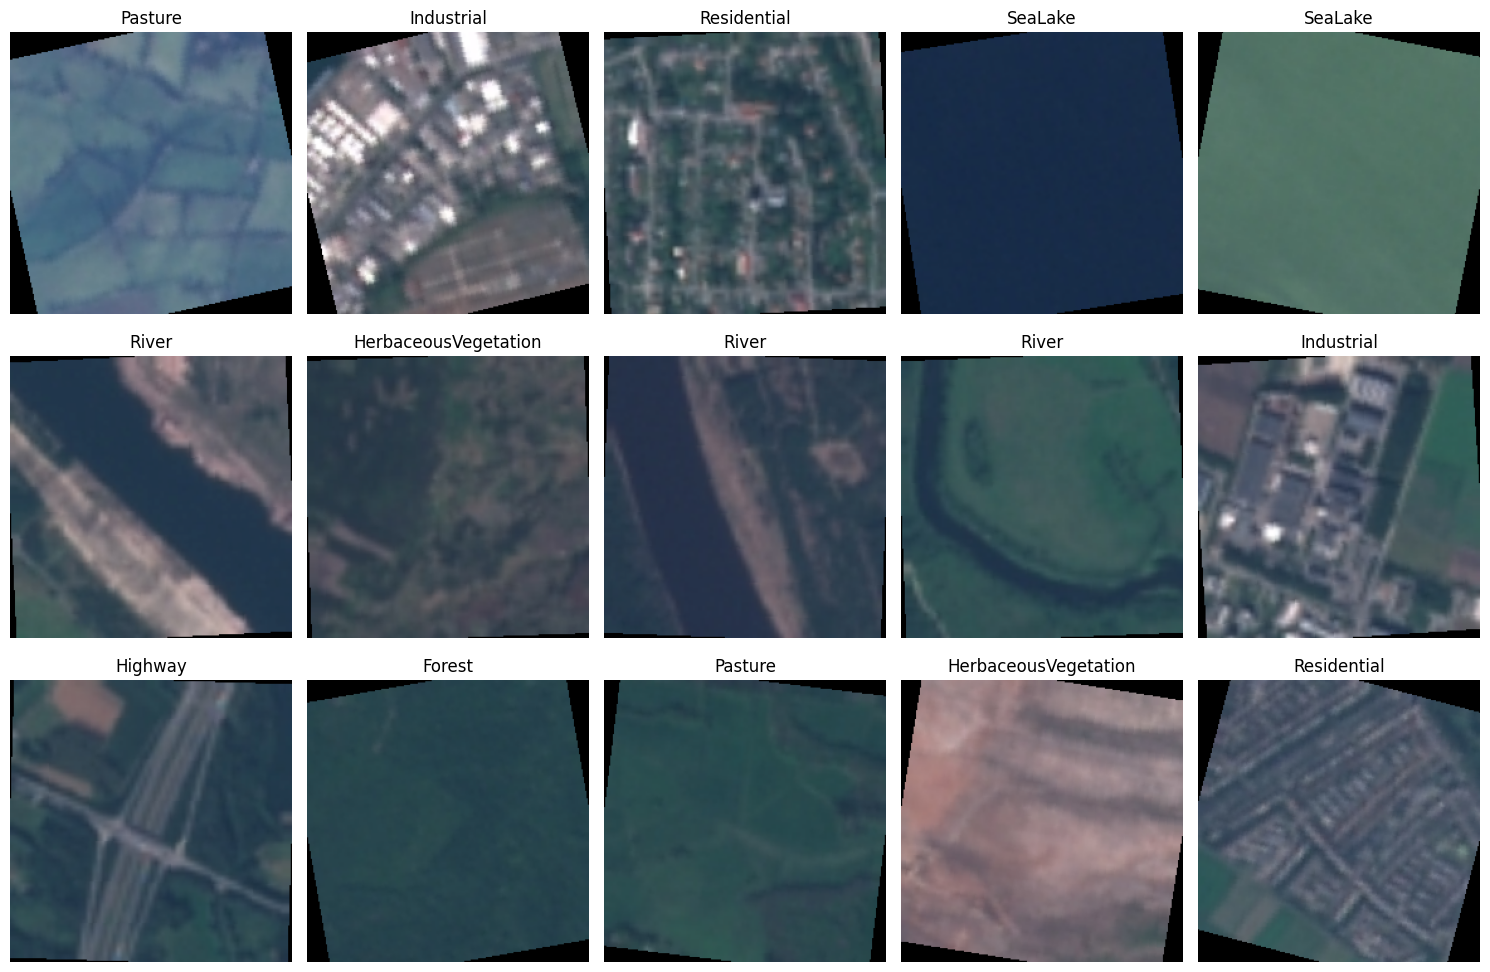

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

fig, ax = plt.subplots(3, 5, figsize=(15, 10))
ax = ax.flatten()

for i in range(15):
    img, label = train[random.randint(0, len(train)-1)]

    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    ax[i].imshow(img)
    ax[i].set_title(labels_for_viz[label])
    ax[i].axis("off")

plt.tight_layout()
plt.show()

Augmentation introduces controlled variations through rotation and flipping operations while preserving class identity. These transformations increase sample diversity and improve model generalization capability.

## Data Loading Pipeline

### DataLoader Creation

DataLoaders enable efficient mini-batch processing during training and evaluation.

In [ ]:
train_dataloader = DataLoader(
    train,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_dataloader = DataLoader(
    val,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_dataloader = DataLoader(
    test,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

img, label = next(iter(train_dataloader))
print("Batch and Image Shape:", img.shape, "--> [batch_size, color_channels, height, width]")
print("\nLabels:", label)

The training DataLoader uses shuffling to reduce learning bias caused by sample ordering, while validation and test sets remain fixed to ensure reproducible evaluation.

## Methodology

### Transfer Learning with ResNet18

Instead of training a convolutional neural network from scratch, transfer learning was selected to leverage feature representations previously learned from large-scale datasets.

***prompt***: generate resnet18 transfer learning code using pytorch with frozen convolutional layers and a new classification layer

***modification prompts***: adapt output layer from imagenet classes to 10 eurosat classes, change optimizer to sgd

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# 1. congelar tudo
for param in model.parameters():
    param.requires_grad = False

# 2. substituir classifier
model.fc = nn.Linear(model.fc.in_features, 10)

# 3. só FC aprende
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

The pre-trained ResNet18 architecture initially acts as a fixed feature extractor. All convolutional layers remain frozen while only the final classification layer learns task-specific representations.

## Training Strategy

### Loss Function and Optimizer

The optimization strategy determines how model parameters are updated during training.

In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.fc.parameters(),
    lr=1e-3,
    momentum=0.9
)

Cross-Entropy Loss was selected because it is suitable for multiclass classification tasks. Stochastic Gradient Descent with momentum was adopted to promote stable convergence.

### Training and Validation Procedure

***prompt***: generate training and validation loop for pytorch model including loss and accuracy calculation

***modification prompts***: add validation history tracking, add model checkpoint saving

In [ ]:
def train_and_validate_model(num_epochs):
    val_best_accuracy = 0.0
    train_loss_history = []
    val_loss_history = []
    train_accuracy_history = []
    val_accuracy_history = []

    print("Training begins...")
    for epoch in range(1, num_epochs+1):
        model.train()
        running_train_loss = 0.0
        running_train_accuracy = 0.0
        train_total = 0
        running_val_accuracy = 0.0
        running_val_loss = 0.0
        val_total = 0


        # TRAINING LOOP
        for data in train_dataloader:
            inputs, outputs = data
            inputs, outputs = inputs.to(device), outputs.to(device)
            optimizer.zero_grad()
            predictions = model(inputs)
            train_loss = loss_fn(predictions, outputs)
            _, train_predicted = torch.max(predictions, 1)
            running_train_accuracy += (train_predicted == outputs).sum().item()
            train_total += outputs.size(0)
            train_loss.backward()
            optimizer.step()
            running_train_loss += train_loss.item()

        train_loss_value = running_train_loss/len(train_dataloader)
        train_loss_history.append(train_loss_value)
        train_accuracy = (100*running_train_accuracy)/train_total
        train_accuracy_history.append(train_accuracy)

        # VALIDATION LOOP
        with torch.no_grad():
            model.eval()
            for data in val_dataloader:
                inputs, outputs = data
                inputs, outputs = inputs.to(device), outputs.to(device)
                predictions = model(inputs)
                val_loss = loss_fn(predictions, outputs)

                _, val_predicted = torch.max(predictions, 1)
                running_val_loss += val_loss.item()
                val_total += outputs.size(0)
                running_val_accuracy += (val_predicted == outputs).sum().item()

        val_loss_value = running_val_loss/len(val_dataloader)
        val_loss_history.append(val_loss_value)
        val_accuracy = (100*running_val_accuracy)/val_total
        val_accuracy_history.append(val_accuracy)

        if val_accuracy > val_best_accuracy:

            torch.save(
                model.state_dict(),
                "model.pth"
            )

            val_best_accuracy = val_accuracy

        print(
            "Completed Epoch:",
            epoch,
            "- Training Accuracy: %.2f" % train_accuracy,
            "- Validation Accuracy: %.2f" % val_accuracy,
            "- Training Loss: %.4f" % train_loss_value,
            "- Validation Loss: %.4f" % val_loss_value
        )

    return train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history

The training loop computes losses and classification accuracy after each epoch. Model checkpointing stores the parameters corresponding to the highest validation accuracy, preventing loss of the best-performing model.

### Phase 1: Feature Extraction

During the initial phase, only the final classification layer is trained while all pre-trained convolutional layers remain frozen.

In [ ]:
EPOCHS_PHASE1 = 5

train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history = train_and_validate_model(EPOCHS_PHASE1)

Training begins...
Completed Epoch: 1 - Training Accuracy: 91.84 - Validation Accuracy: 90.15 - Training Loss: 0.2444 - Validation Loss: 0.3009
Completed Epoch: 2 - Training Accuracy: 91.83 - Validation Accuracy: 89.78 - Training Loss: 0.2420 - Validation Loss: 0.3146
Completed Epoch: 3 - Training Accuracy: 91.99 - Validation Accuracy: 89.44 - Training Loss: 0.2404 - Validation Loss: 0.3169
Completed Epoch: 4 - Training Accuracy: 92.15 - Validation Accuracy: 90.17 - Training Loss: 0.2339 - Validation Loss: 0.2928
Completed Epoch: 5 - Training Accuracy: 92.36 - Validation Accuracy: 90.41 - Training Loss: 0.2339 - Validation Loss: 0.2953


Validation accuracy reached approximately 90%, indicating that ImageNet representations already capture highly informative features relevant for satellite image classification.

### Phase 2: Fine-Tuning

Fine-tuning allows higher-level features to adapt to domain-specific image characteristics.

In [ ]:
# Fine-tuning

# descongelar última camada da ResNet
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD(
    model.parameters(),   # agora inclui fc + layer4
    lr=1e-4,              # mais pequeno
    momentum=0.9
)

EPOCHS_PHASE2 = 10

train_accuracy_history2,\
val_accuracy_history2,\
train_loss_history2,\
val_loss_history2 = \
train_and_validate_model(EPOCHS_PHASE2)

Training begins...
Completed Epoch: 1 - Training Accuracy: 95.59 - Validation Accuracy: 94.65 - Training Loss: 0.1314 - Validation Loss: 0.1622
Completed Epoch: 2 - Training Accuracy: 95.85 - Validation Accuracy: 94.33 - Training Loss: 0.1216 - Validation Loss: 0.1764
Completed Epoch: 3 - Training Accuracy: 96.33 - Validation Accuracy: 94.93 - Training Loss: 0.1083 - Validation Loss: 0.1567
Completed Epoch: 4 - Training Accuracy: 96.91 - Validation Accuracy: 95.15 - Training Loss: 0.0907 - Validation Loss: 0.1443
Completed Epoch: 5 - Training Accuracy: 96.84 - Validation Accuracy: 95.20 - Training Loss: 0.0917 - Validation Loss: 0.1449
Completed Epoch: 6 - Training Accuracy: 96.67 - Validation Accuracy: 95.15 - Training Loss: 0.0946 - Validation Loss: 0.1439
Completed Epoch: 7 - Training Accuracy: 96.88 - Validation Accuracy: 95.22 - Training Loss: 0.0897 - Validation Loss: 0.1442
Completed Epoch: 8 - Training Accuracy: 96.94 - Validation Accuracy: 95.19 - Training Loss: 0.0905 - Valid

Unfreezing the last residual block enabled the model to learn representations more suitable for satellite imagery, resulting in improved validation performance.

## Results and Performance Evaluation

### Learning Curves

***prompt***: generate training and validation learning curves for loss and accuracy

In [ ]:
def test_model():
    model = resnet18(weights=None)   # evita re-download
    model.fc = nn.Linear(512, 10)

    model = model.to(device)

    model.load_state_dict(torch.load("model.pth", map_location=device))
    model.eval()

    running_accuracy = 0
    total = 0
    all_predictions = []

    with torch.no_grad():
        for inputs, outputs in test_dataloader:
            inputs, outputs = inputs.to(device), outputs.to(device)

            predictions = model(inputs)
            _, predicted = torch.max(predictions, 1)

            total += outputs.size(0)
            running_accuracy += (predicted == outputs).sum().item()

            all_predictions.append(predicted.cpu().numpy())

    print("Test Accuracy:", 100 * running_accuracy / total)

    return np.hstack(all_predictions)

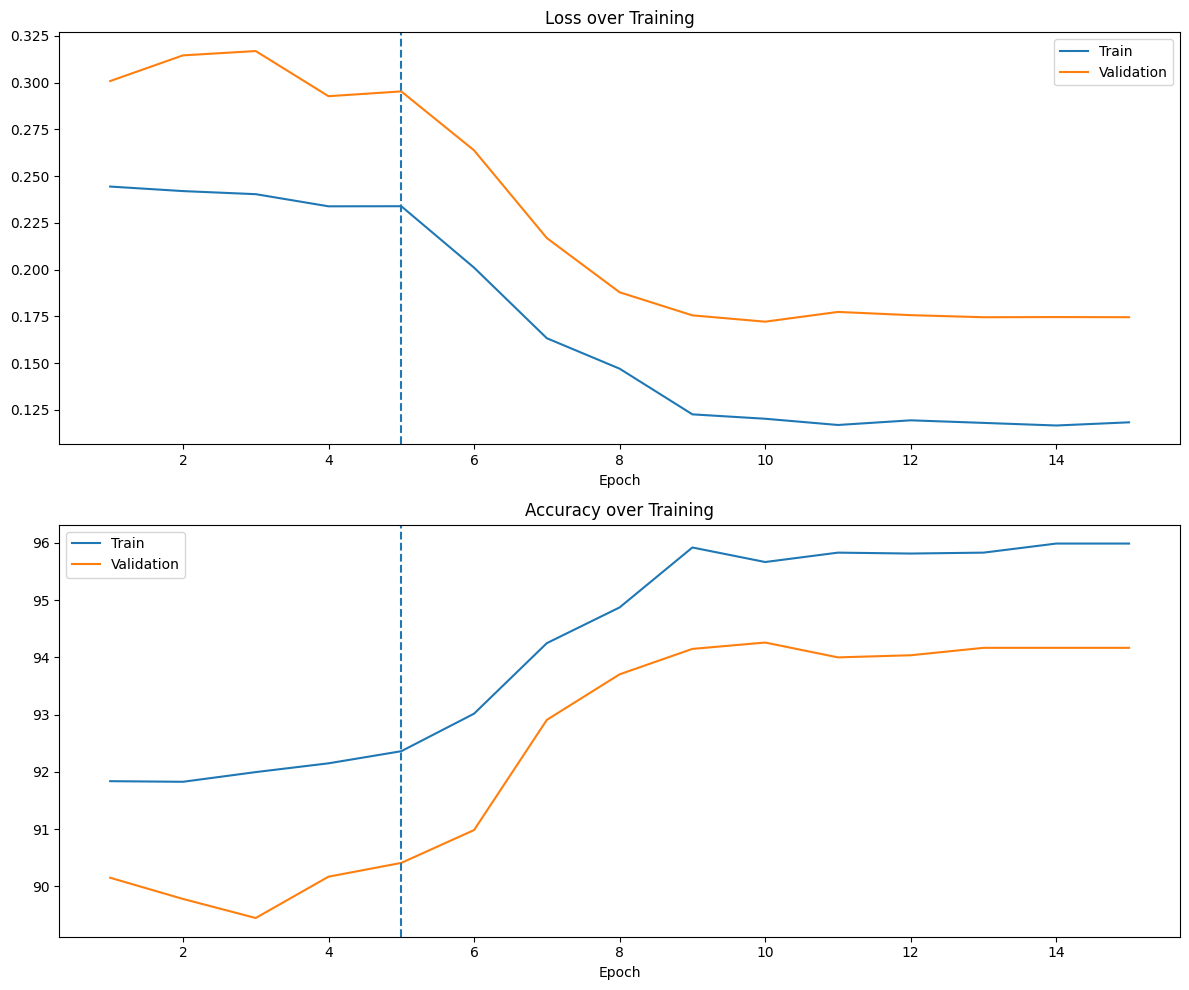

In [ ]:
# gráficos das duas fases juntas

train_acc = train_accuracy_history + train_accuracy_history2
val_acc = val_accuracy_history + val_accuracy_history2

train_loss = train_loss_history + train_loss_history2
val_loss = val_loss_history + val_loss_history2

epochs = range(
    1,
    len(train_acc)+1
)

fig, ax = plt.subplots(
    2,
    1,
    figsize=(12,10)
)

ax[0].plot(
    epochs,
    train_loss,
    label="Train"
)

ax[0].plot(
    epochs,
    val_loss,
    label="Validation"
)

ax[0].axvline(
    x=5,
    linestyle='--'
)

ax[0].set_title(
    "Loss over Training"
)

ax[0].set_xlabel(
    "Epoch"
)

ax[0].legend()

ax[1].plot(
    epochs,
    train_acc,
    label="Train"
)

ax[1].plot(
    epochs,
    val_acc,
    label="Validation"
)

ax[1].axvline(
    x=5,
    linestyle='--'
)

ax[1].set_title(
    "Accuracy over Training"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].legend()

plt.tight_layout()

plt.show()

The learning curves indicate stable convergence with only a small gap between training and validation performance, suggesting limited overfitting.

### Classification Report

***prompt***: generate classification report for multiclass image classification

In [ ]:
from sklearn.metrics import classification_report

all_preds = test_model()

y_true = np.array(test.targets)
y_pred = np.array(all_preds).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test.class_to_idx.keys())
))

Test Accuracy: 94.66666666666667
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.91      0.93       300
              Forest       0.98      0.98      0.98       300
HerbaceousVegetation       0.94      0.92      0.93       300
             Highway       0.90      0.92      0.91       250
          Industrial       0.96      0.96      0.96       250
             Pasture       0.95      0.95      0.95       200
       PermanentCrop       0.88      0.91      0.89       250
         Residential       0.97      1.00      0.98       300
               River       0.92      0.94      0.93       250
             SeaLake       0.99      0.97      0.98       300

            accuracy                           0.95      2700
           macro avg       0.95      0.95      0.95      2700
        weighted avg       0.95      0.95      0.95      2700



Performance metrics demonstrate strong classification capability across most categories. Lower scores among vegetation-related classes indicate difficulty distinguishing visually similar patterns.

### Macro F1 Score

Since overall accuracy alone may not fully describe performance across classes, macro-averaged metrics are also examined.

In [ ]:
print("Macro F1-score:",
      classification_report(
          y_true,
          y_pred,
          output_dict=True
      )["macro avg"]["f1-score"])

Macro F1-score: 0.9453851869939717


The macro F1-score indicates balanced performance across categories and suggests that classification quality is consistent among classes.

### Confusion Matrix

***prompt***: generate normalized confusion matrix visualization using seaborn

***modification prompt***: add percentage normalization

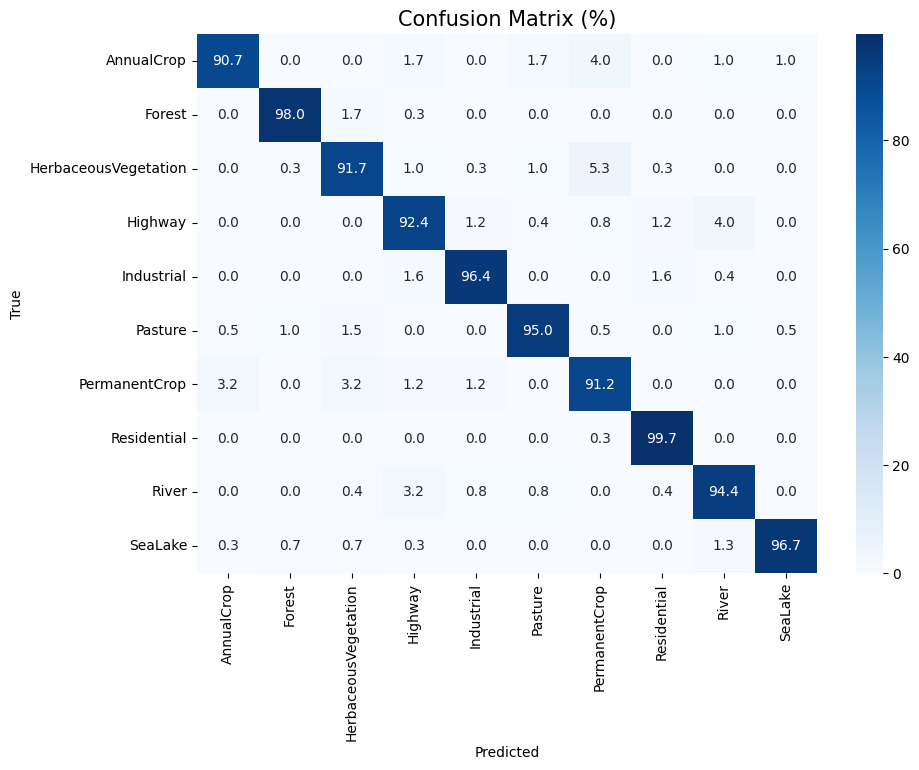

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test.targets, all_preds, normalize='true') * 100

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt=".1f",   # <- CORRETO para floats
    xticklabels=list(test.class_to_idx.keys()),
    yticklabels=list(test.class_to_idx.keys())
)

plt.title("Confusion Matrix (%)", size=15)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Strong diagonal values indicate successful class separation. Misclassification patterns predominantly occur among vegetation classes, supporting previous observations regarding visual similarity.

### Manual Prediction Example

***prompt***: generate code for manual prediction testing using a randomly selected image

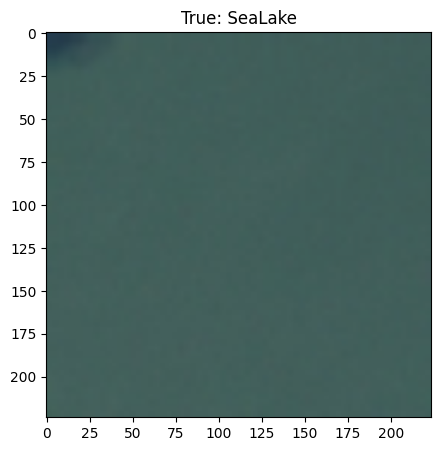

Predicted: SeaLake
True: SeaLake


In [ ]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return image.cpu() * std + mean

idx = random.randint(0, len(test) - 1)

image, label = test[idx]

idx_to_class = {v: k for k, v in test.class_to_idx.items()}

# Visualização correta
plt.figure(figsize=(5,5))
plt.imshow(denormalize(image).permute(1,2,0))
plt.title(f"True: {idx_to_class[label]}")
plt.show()

# Previsão
# carregar melhor modelo guardado

model.load_state_dict(
    torch.load(
        "model.pth",
        map_location=device
    )
)

model.eval()

with torch.no_grad():

    output = model(
        image.to(device).unsqueeze(0)
    )

    pred = torch.argmax(
        output,
        dim=1
    ).item()

print("Predicted:", idx_to_class[pred])
print("True:", idx_to_class[label])

The manually selected sample was correctly classified, providing qualitative evidence that the model generalizes effectively to unseen examples.

## Discussion

Forest and SeaLake classes achieved stronger performance because they possess distinctive visual characteristics. In contrast, PermanentCrop and HerbaceousVegetation exhibit overlapping textures and spectral patterns, increasing classification complexity.

Future improvements could include stronger augmentation strategies, deeper architectures such as ResNet50 or EfficientNet, and geographically separated train-test splits.

## Conclusion

This project successfully applied transfer learning using ResNet18 for multiclass satellite image classification. The use of frozen layers followed by fine-tuning improved performance while reducing training requirements compared to training a CNN from scratch.

Learning curves suggested stable convergence with limited overfitting, while the classification report and confusion matrix demonstrated strong predictive performance across most classes. Classification errors occurred mainly among visually similar vegetation categories.

Overall, transfer learning proved to be an effective approach for satellite image classification, achieving strong performance while remaining computationally efficient.

## References


Helber, P., et al. "EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification." IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 2019.

Raschka, S., Liu, Y., Mirjalili, V. Machine Learning with PyTorch and Scikit-Learn. Packt Publishing, 2022.

PyTorch documentation:
[PyTorch](https://pytorch.org/)

Kaggle EuroSAT dataset:
[EuroSAT Dataset](https://www.kaggle.com/datasets/waseemalastal/eurosat-rgb-dataset)

He et al., "Deep Residual Learning for Image Recognition", CVPR 2016.

## Contributions